In [ ]:
import torch
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ps
import numpy as np
from preprocess_data import *
import models as models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd
import sys
import os
from process_attribution import *
from plots import *
from scipy.sparse import coo_matrix

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'serif']
plt.rcParams['pdf.fonttype'] = 42  # Use TrueType fonts in PDF

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df = pd.read_csv('tables/units_info.csv')
# print(df.head())

      unit_id  session_id                                       genotype  \
0  1179685687  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
1  1179685618  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
2  1179685304  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
3  1179685455  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
4  1179684888  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   

   optotagged  cluster_id  firing_rate  response_mag  sparsity  \
0           0           0     2.347611     -0.165334 -0.110431   
1           0           0     0.608558     -0.119121 -0.137173   
2           0           0     0.932567      0.146078  0.053006   
3           0           4    11.398961     -0.184356 -0.109291   
4           0           0     8.338130      0.441873 -0.053603   

   waveform_duration  pyr  ...  coher_2_5  coher_5_10  num_conn_e_to_e  \
0           0.645561    1  ...   0.419711    0.420402              NaN  

In [ ]:
# Session obj contains stimulus, channel, and unit information
output_dir  = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022')
session_id  = 1119946360
session_obj = ps(session_id, df, output_dir)
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
criterion  = torch.nn.MSELoss()
input_size = len(session_obj.units)
num_epochs = 15 # 
batch_size = 32

# hyperparameters
hidden_size = 50 # 
num_layers = 1
seqlength = 750

# define output directory for saved models
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)
output_dir_plots = output_dir_models / 'plots'
os.makedirs(output_dir_models, exist_ok=True)
os.makedirs(output_dir_plots, exist_ok=True)

In [ ]:
# --- 2. Load Spiking Data ---
bin_size  = 0.004
time_win = [-.25, .5]
baseline_win = [-.25, 0]

spikes_obj = pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.truncate(750) 

t = np.arange(time_win[0], time_win[1], bin_size)
n_bins_snippet = len(t)
timestamps = spikes_obj.timestamps
n_timepoints_total = len(timestamps)

# Filter stimulus times (Active & non-omitted)
stim_df = session_obj.stimulus_presentation
stim_mask = (stim_df.active == True) & (stim_df.image_name != "omitted")
stim_st = stim_df.start_time[stim_mask].values

# Ensure trials stay within session bounds
valid_trials_mask = ((stim_st + time_win[0]) >= timestamps[0]) & ((stim_st + time_win[1]) < timestamps[-1])
stim_st = stim_st[valid_trials_mask]
n_trials = len(stim_st)
print(f"Valid trials for analysis: {n_trials}")

# Calculate PSTH
print("Calculating PSTH")
n_neurons = spikes_obj.spkMat.shape[1]
psth = np.zeros((n_neurons, n_bins_snippet), dtype=np.float32)
for i in range(n_trials):
    start_idx = np.searchsorted(timestamps, stim_st[i] + time_win[0])
    if start_idx + n_bins_snippet <= n_timepoints_total:
        psth += spikes_obj.spkMat[start_idx : start_idx + n_bins_snippet, :].T
psth /= (n_trials * bin_size)
print("PSTH successfully computed")


Valid trials for analysis: 4633
Calculating PSTH
PSTH successfully computed


In [3]:
# Spikes obj contains Spike matrix
bin_size=0.004
sr = 1/bin_size
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[0]+10)
spikes_obj.truncate(seqlength)
spikes_obj.minmax()

# Probe obj contains LFP data
# Getting LFP  for active trials
lfp_obj = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
                              session_obj.active_times[0]+10, output_dir) 
lfp_obj.filter_lfp(take_power = True)
lfp_obj.downsample_lfp(int(1250 /sr)) # Downsample by 5
lfp_obj.truncate(seqlength)
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])
num_channels = len(lfp_obj.channels)

In [11]:
ch_val = 6
sparse_attr = np.load(output_dir_models / f'attribution_scores_chan{ch_val}_band{0}.npz') 
attrs = coo_matrix((sparse_attr['data'], (sparse_attr['row'], sparse_attr['col'])), 
                    shape=sparse_attr['shape']).toarray().astype(np.float32)
attrs = attrs[:spikes_obj.spkMat.shape[0], :]


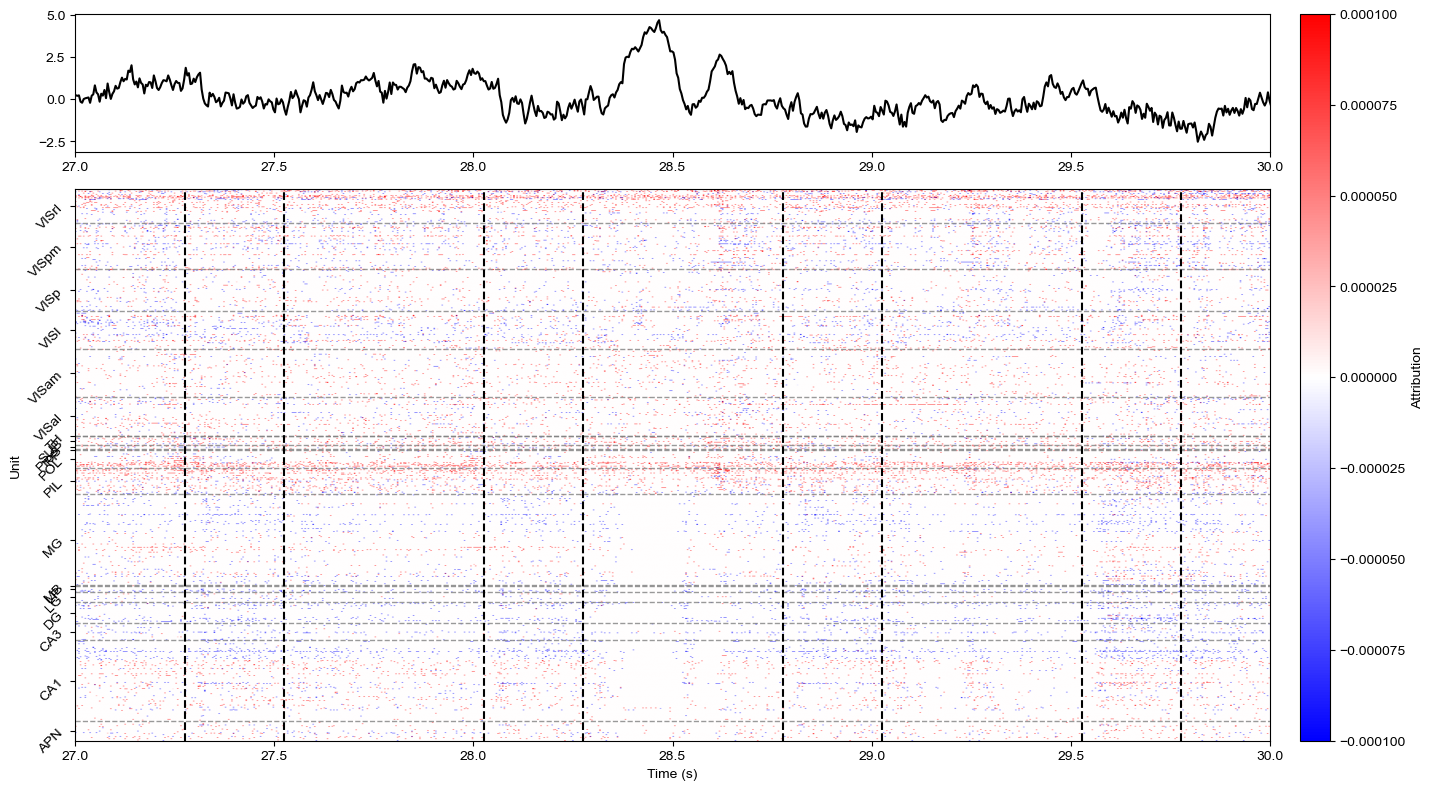

Plot saved successfully to: Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\figures\attr_matrix.pdf


In [40]:
import importlib
import plots
importlib.reload(plots)
from plots import * 

plot_attr_matrix(attrs, lfp_obj.lfpMat[:,6,0], spikes_obj.timestamps, 
                 session_obj, [27, 30], 
                 plot_stim=True, save_fig=True, session_id=session_id,
                 output_dir=r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\figures')